In [34]:
import pandas as pd
import pandas as pd
import streamlit as st
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [3]:
df = pd.read_csv(r"C:\Users\hp\Downloads\Financial_inclusion_dataset.csv") 

In [5]:
df.info

<bound method DataFrame.info of       country  year       uniqueid bank_account location_type  \
0       Kenya  2018     uniqueid_1          Yes         Rural   
1       Kenya  2018     uniqueid_2           No         Rural   
2       Kenya  2018     uniqueid_3          Yes         Urban   
3       Kenya  2018     uniqueid_4           No         Rural   
4       Kenya  2018     uniqueid_5           No         Urban   
...       ...   ...            ...          ...           ...   
23519  Uganda  2018  uniqueid_2113           No         Rural   
23520  Uganda  2018  uniqueid_2114           No         Rural   
23521  Uganda  2018  uniqueid_2115           No         Rural   
23522  Uganda  2018  uniqueid_2116           No         Urban   
23523  Uganda  2018  uniqueid_2117           No         Rural   

      cellphone_access  household_size  age_of_respondent  \
0                  Yes               3                 24   
1                   No               5                 70   
2   

In [4]:
df.shape

(23524, 13)

In [6]:
df.head

<bound method NDFrame.head of       country  year       uniqueid bank_account location_type  \
0       Kenya  2018     uniqueid_1          Yes         Rural   
1       Kenya  2018     uniqueid_2           No         Rural   
2       Kenya  2018     uniqueid_3          Yes         Urban   
3       Kenya  2018     uniqueid_4           No         Rural   
4       Kenya  2018     uniqueid_5           No         Urban   
...       ...   ...            ...          ...           ...   
23519  Uganda  2018  uniqueid_2113           No         Rural   
23520  Uganda  2018  uniqueid_2114           No         Rural   
23521  Uganda  2018  uniqueid_2115           No         Rural   
23522  Uganda  2018  uniqueid_2116           No         Urban   
23523  Uganda  2018  uniqueid_2117           No         Rural   

      cellphone_access  household_size  age_of_respondent  \
0                  Yes               3                 24   
1                   No               5                 70   
2     

In [7]:
#report = ProfileReport(data)
#report.to_notebook_iframe()

In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.columns

Index(['country', 'year', 'uniqueid', 'bank_account', 'location_type',
       'cellphone_access', 'household_size', 'age_of_respondent',
       'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type'],
      dtype='object')

In [12]:
df.describe

<bound method NDFrame.describe of       country  year       uniqueid bank_account location_type  \
0       Kenya  2018     uniqueid_1          Yes         Rural   
1       Kenya  2018     uniqueid_2           No         Rural   
2       Kenya  2018     uniqueid_3          Yes         Urban   
3       Kenya  2018     uniqueid_4           No         Rural   
4       Kenya  2018     uniqueid_5           No         Urban   
...       ...   ...            ...          ...           ...   
23519  Uganda  2018  uniqueid_2113           No         Rural   
23520  Uganda  2018  uniqueid_2114           No         Rural   
23521  Uganda  2018  uniqueid_2115           No         Rural   
23522  Uganda  2018  uniqueid_2116           No         Urban   
23523  Uganda  2018  uniqueid_2117           No         Rural   

      cellphone_access  household_size  age_of_respondent  \
0                  Yes               3                 24   
1                   No               5                 70   
2 

In [20]:
# Handle missing values
print(df.isnull().sum())

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


In [21]:
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

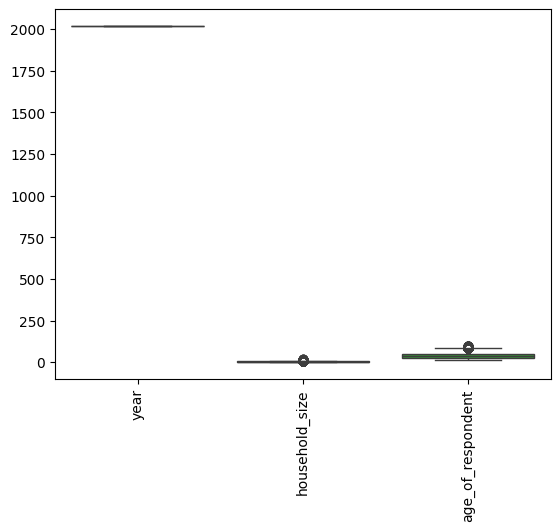

In [26]:
# Detect outliers with boxplots
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

In [27]:
# Encode Categorical Features
df_encoded = pd.get_dummies(df, drop_first=True)

In [28]:
# Separate features and target
X = df_encoded.drop('bank_account_Yes', axis=1)  # Replace with your actual target column
y = df_encoded['bank_account_Yes'] 

In [30]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Train
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      0.98      0.94      4063
        True       0.73      0.30      0.42       642

    accuracy                           0.89      4705
   macro avg       0.81      0.64      0.68      4705
weighted avg       0.87      0.89      0.87      4705

Accuracy: 0.8888416578108396


In [33]:
# Save model
import joblib
joblib.dump(model, 'financial_model.pkl')

['financial_model.pkl']

In [36]:
joblib.dump(model,r"C:\Users\hp\Downloads\Financial_inclusion_dataset.csv") 

['C:\\Users\\hp\\Downloads\\Financial_inclusion_dataset.csv']